# Unsupervised Learning
Unsupervised learning was used to explore the underlying structure of the cardiovascular disease dataset without using the cardio target during model training. The goal was to identify natural patient groups based on demographic, clinical, and lifestyle characteristics. Three clustering approaches were explored:
- K-Means
- DBSCAN

### K-Means Clustering
K-Means was applied to identify natural groups of patients. The features were standardized before clustering because K-Means relies on distance calculations. The Elbow Method and Silhouette Score were used to determine an appropriate number of clusters.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)

Dataset shape: (68742, 13)


In [4]:
from sklearn.preprocessing import StandardScaler

cluster_features = ["age_years", "gender","height","weight","ap_hi", "ap_lo", "cholesterol","gluc", "smoke","alco","active"]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

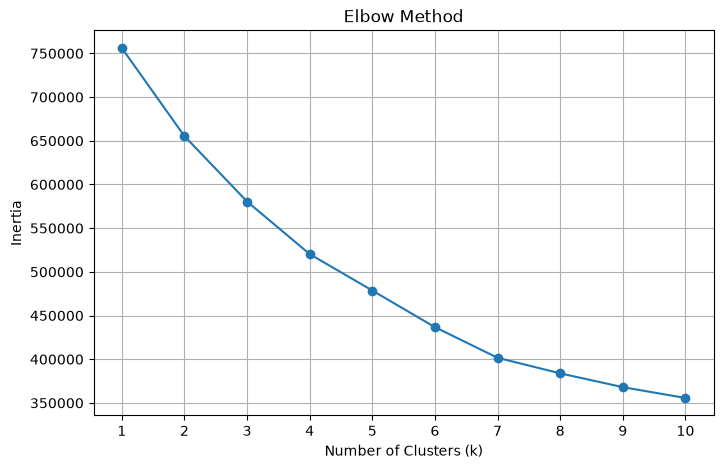

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    
    print(f"k={k} | Silhouette Score={score:.4f}")

k=2 | Silhouette Score=0.1785
k=3 | Silhouette Score=0.1888
k=4 | Silhouette Score=0.1842
k=5 | Silhouette Score=0.1956
k=6 | Silhouette Score=0.1915
k=7 | Silhouette Score=0.2015
k=8 | Silhouette Score=0.1584
k=9 | Silhouette Score=0.1624
k=10 | Silhouette Score=0.1631


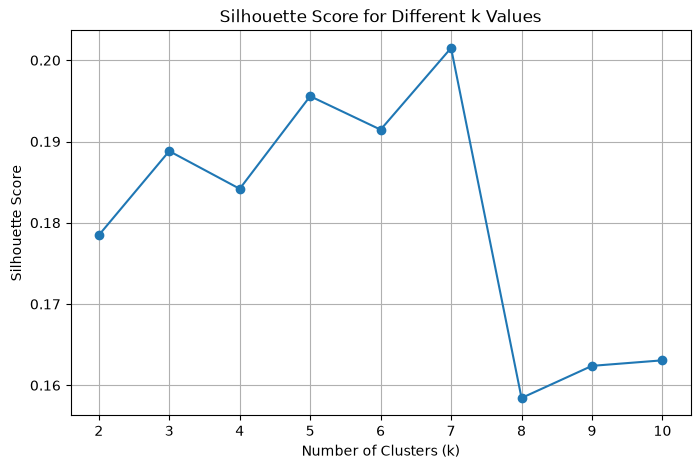

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")

plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [8]:
best_k = 7 

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

print(df["cluster"].value_counts().sort_index()) 
cluster_profile = df.groupby("cluster")[cluster_features].mean()
cluster_profile.round(2)

cluster
0    11804
1    22115
2    10346
3    11094
4     3646
5     4077
6     5660
Name: count, dtype: int64


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
cluster,,,,,,,,,,,
0,52.73,1.98,170.85,76.84,124.53,80.55,1.18,1.06,0.00,0.00,0.99
1,52.10,1.01,161.38,68.42,117.29,76.44,1.14,1.05,0.00,0.00,1.00
2,53.04,1.31,164.21,72.67,123.54,79.85,1.20,1.07,0.00,0.00,0.00
3,55.86,1.13,161.36,79.88,147.59,92.11,1.60,1.10,0.00,0.00,0.93
4,52.41,1.70,167.78,78.15,128.76,83.04,1.45,1.23,0.50,1.00,0.84
5,52.27,1.86,169.31,76.98,127.31,81.69,1.33,1.16,1.00,0.00,0.83
6,55.84,1.25,163.27,77.48,130.04,82.92,2.41,2.85,0.02,0.01,0.81


### DBSCAN Clustering 
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) was applied as a density-based alternative to K-Means.
Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance. It groups observations based on density and can identify observations in sparse regions as noise.

The eps parameter was selected using a k-distance plot. The plot showed a noticeable increase in distance between approximately 2 and 3, so eps = 2.5 was selected.

The final DBSCAN configuration used: 
- eps = 2.5
- min_samples = 10


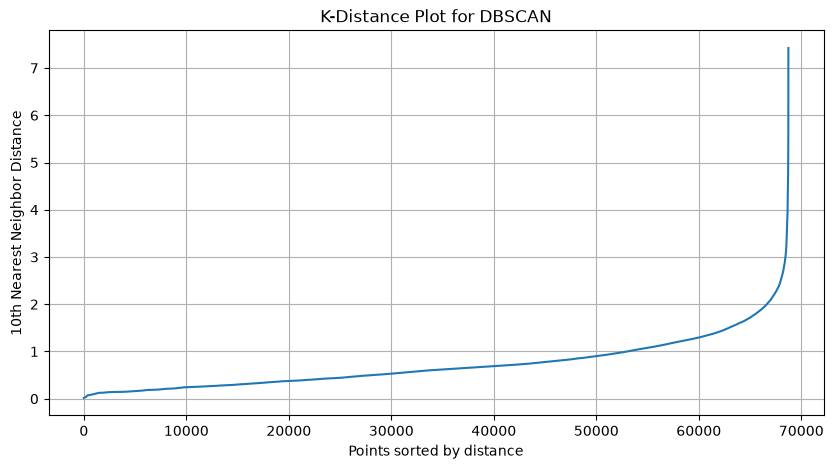

In [9]:
from sklearn.neighbors import NearestNeighbors 
neighbors = NearestNeighbors(n_neighbors=11)
neighbors_fit = neighbors.fit(X_scaled) 

distances, indices = neighbors_fit.kneighbors(X_scaled) 

k_distances = np.sort(distances[:, 10])

plt.figure(figsize=(10, 5)) 
plt.plot(k_distances) 

plt.xlabel("Points sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance") 
plt.title("K-Distance Plot for DBSCAN") 
plt.grid(True) 
plt.show()

In [10]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN( eps=2.5, 
    min_samples=10, 
    algorithm="ball_tree",
    n_jobs=-1 ) 

db_labels = dbscan.fit_predict(X_scaled) 

n_clusters = len(set(db_labels) - {-1}) 
n_noise = np.sum(db_labels == -1)

print("Number of clusters:", n_clusters) 
print("Number of noise points:", n_noise)

Number of clusters: 8
Number of noise points: 252


In [11]:
from sklearn.metrics import silhouette_score

mask = db_labels != -1

dbscan_silhouette = silhouette_score(
    X_scaled[mask],
    db_labels[mask]
)

print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.19083805999924533


In [12]:
cluster_counts = pd.Series(db_labels).value_counts().sort_index()

print(cluster_counts)

-1      252
 0    48528
 1    12192
 2     1511
 3     3497
 4     1539
 5      254
 6      699
 7      270
Name: count, dtype: int64


In [13]:
df["dbscan_cluster"] = db_labels

dbscan_profile = (
    df[df["dbscan_cluster"] != -1]
    .groupby("dbscan_cluster")[cluster_features]
    .mean()
)

dbscan_profile.round(2)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
dbscan_cluster,,,,,,,,,,,
0,53.38,1.29,163.80,73.53,126.38,81.19,1.36,1.22,0.0,0.0,1.0
1,53.49,1.30,164.17,74.00,126.40,81.17,1.34,1.23,0.0,0.0,0.0
2,51.78,1.92,170.08,76.46,128.23,82.32,1.37,1.18,1.0,1.0,1.0
3,52.38,1.86,169.22,76.52,127.47,81.71,1.38,1.22,1.0,0.0,1.0
4,53.00,1.48,165.44,78.26,128.99,82.74,1.54,1.29,0.0,1.0,1.0
5,51.57,1.91,169.51,79.98,129.04,82.53,1.34,1.13,1.0,1.0,0.0
6,52.79,1.82,168.91,79.04,127.86,81.80,1.39,1.20,1.0,0.0,0.0
7,54.08,1.43,164.84,79.90,127.64,82.14,1.48,1.22,0.0,1.0,0.0


In [14]:
dbscan_cardio = pd.crosstab(
    df[df["dbscan_cluster"] != -1]["dbscan_cluster"],
    df[df["dbscan_cluster"] != -1]["cardio"],
    normalize="index"
) * 100

dbscan_cardio.round(2)

cardio,0,1
dbscan_cluster,,
0,51.22,48.78
1,46.84,53.16
2,58.31,41.69
3,53.50,46.50
4,48.86,51.14
5,47.24,52.76
6,45.78,54.22
7,50.00,50.00


# Conclusion 
The unsupervised learning experiments provided additional insight into the structure of the patient population. K-Means produced the strongest Silhouette Score among the tested clustering methods and identified a cluster with a particularly high cardiovascular disease prevalence.